# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Medical Cost Personal Dataset (Insurance)** yang bersumber dari Kaggle.

- **Sumber:** https://www.kaggle.com/datasets/mirichoi0218/insurance
- **Jumlah Data:** 1338 baris, 7 kolom
- **Task:** Regresi - memprediksi biaya asuransi kesehatan (`charges`)

### Deskripsi Fitur:
| Fitur | Tipe | Deskripsi |
|---|---|---|
| age | Numerik | Usia pemegang polis |
| sex | Kategorikal | Jenis kelamin (male/female) |
| bmi | Numerik | Body Mass Index |
| children | Numerik | Jumlah tanggungan |
| smoker | Kategorikal | Status perokok (yes/no) |
| region | Kategorikal | Wilayah (northeast/northwest/southeast/southwest) |
| charges | Numerik | **Target** — biaya asuransi (USD) |

# **2. Import Library**

In [1]:
!pip install kaggle -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Library berhasil diimport!')
print(f'Pandas version: {pd.__version__}')
print(f'Numpy version: {np.__version__}')

Library berhasil diimport!
Pandas version: 2.3.3
Numpy version: 2.0.2


# **3. Memuat Dataset**

In [2]:
import os
from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()

api.dataset_download_files('mirichoi0218/insurance', path='./', unzip=True)
print('Dataset berhasil didownload!')

Dataset URL: https://www.kaggle.com/datasets/mirichoi0218/insurance
Dataset berhasil didownload!


In [3]:
df = pd.read_csv('insurance.csv')

print('Shape dataset:', df.shape)
print('\n5 baris pertama:')
df.head()

Shape dataset: (1338, 7)

5 baris pertama:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print('=== Info Dataset ===')
df.info()
print('\n=== Statistik Deskriptif ===')
df.describe()

=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Statistik Deskriptif ===


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


# **4. Exploratory Data Analysis (EDA)**

In [5]:
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

=== Missing Values ===
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Total missing values: 0


In [6]:
print(f'Jumlah duplikat: {df.duplicated().sum()}')
df_clean = df.drop_duplicates()
print(f'Shape setelah hapus duplikat: {df_clean.shape}')

Jumlah duplikat: 1
Shape setelah hapus duplikat: (1337, 7)


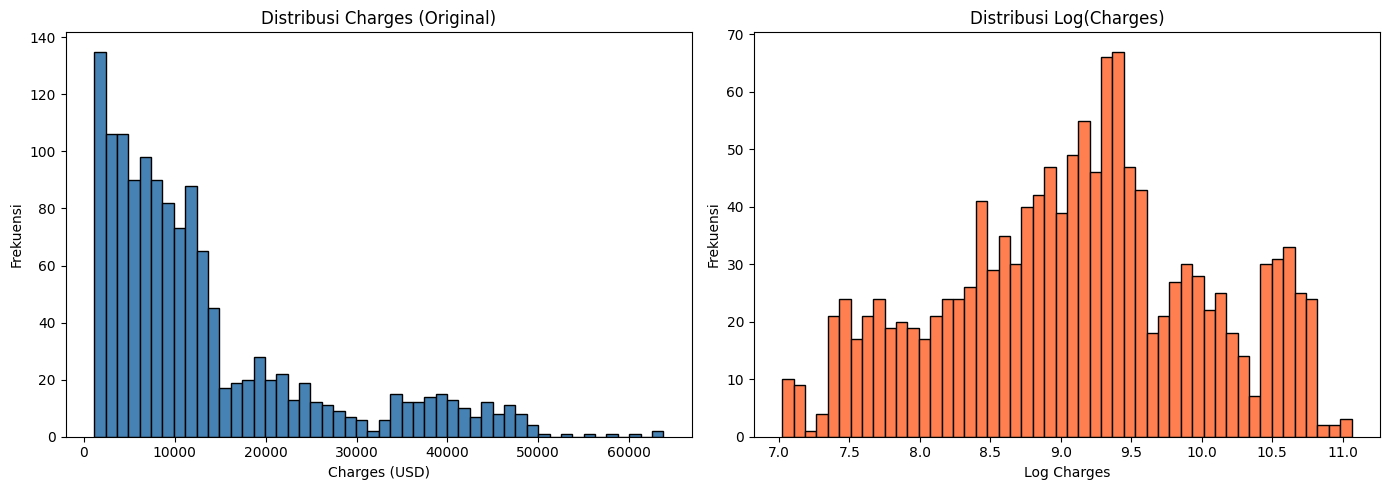

Target variable memiliki distribusi right-skewed, perlu diperhatikan.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['charges'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribusi Charges (Original)')
axes[0].set_xlabel('Charges (USD)')
axes[0].set_ylabel('Frekuensi')

axes[1].hist(np.log1p(df_clean['charges']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribusi Log(Charges)')
axes[1].set_xlabel('Log Charges')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_charges_distribution.png', dpi=100, bbox_inches='tight')
plt.show()
print('Target variable memiliki distribusi right-skewed, perlu diperhatikan.')

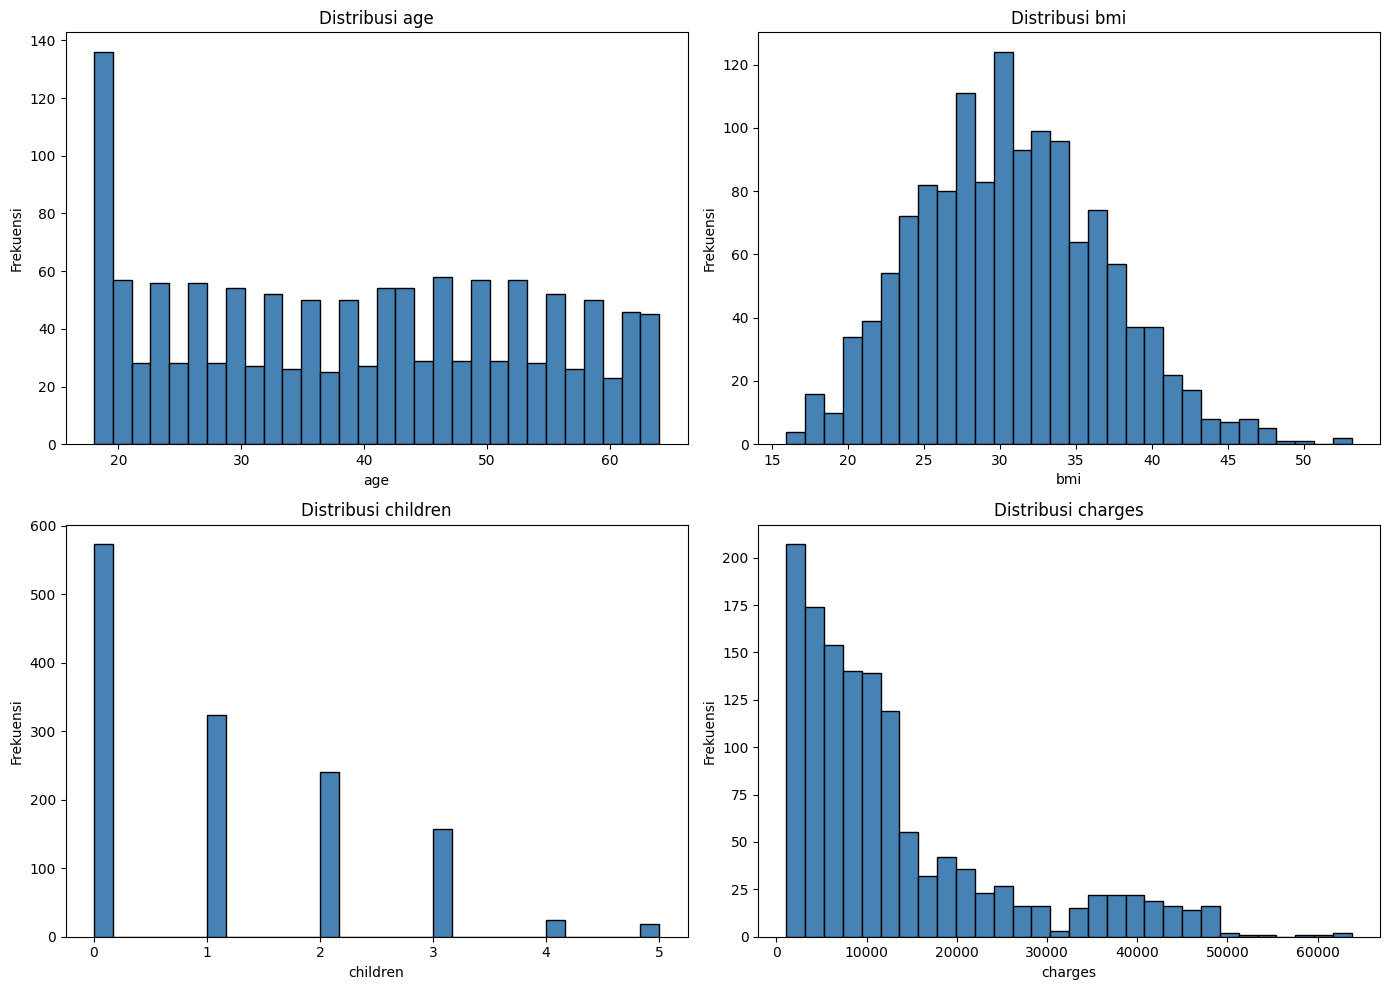

In [8]:
num_cols = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_clean[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_numeric_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

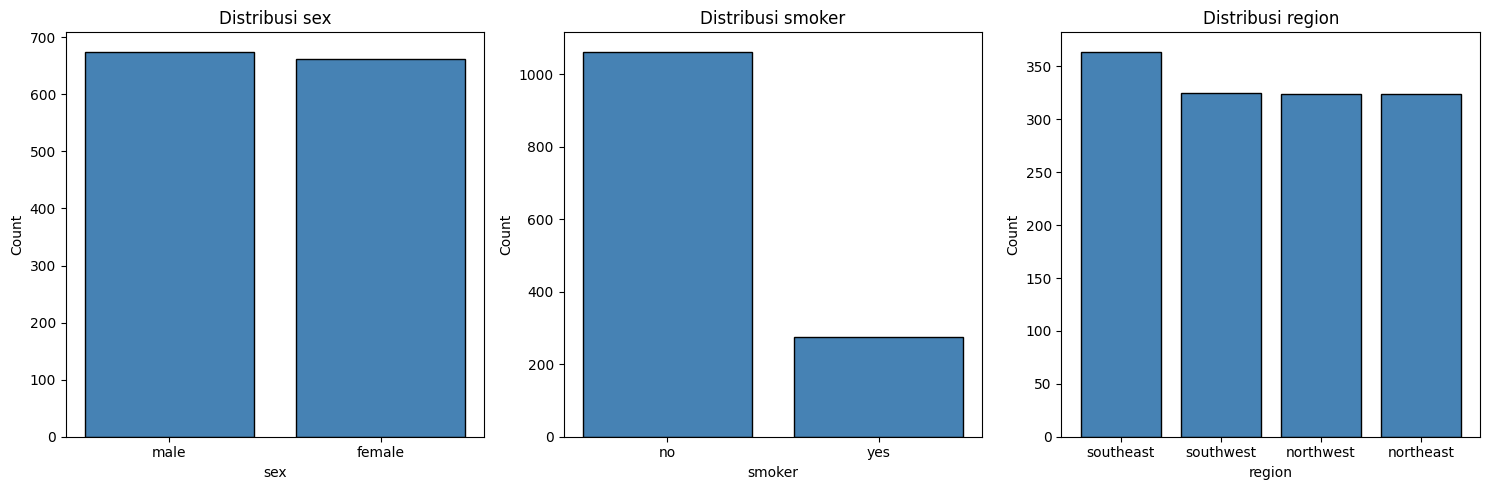

In [9]:
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(cat_cols):
    counts = df_clean[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_categorical_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

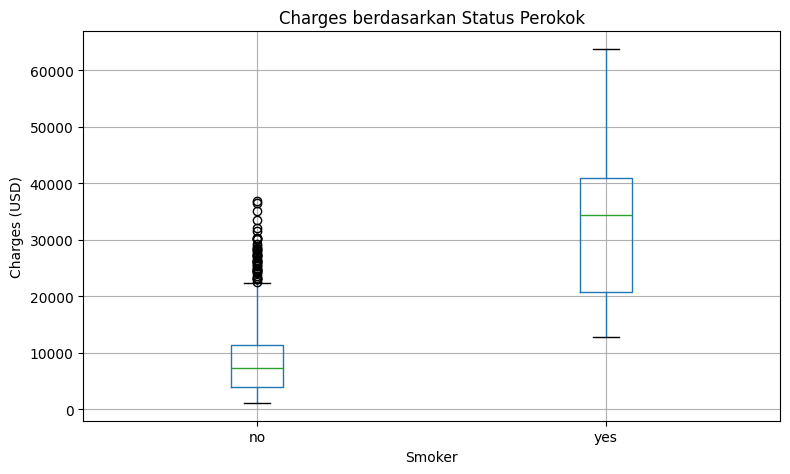

Rata-rata charges per kategori smoker:
smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
df_clean.boxplot(column='charges', by='smoker', ax=ax)
ax.set_title('Charges berdasarkan Status Perokok')
ax.set_xlabel('Smoker')
ax.set_ylabel('Charges (USD)')
plt.suptitle('')
plt.tight_layout()
plt.savefig('eda_smoker_charges.png', dpi=100, bbox_inches='tight')
plt.show()

print('Rata-rata charges per kategori smoker:')
print(df_clean.groupby('smoker')['charges'].mean())

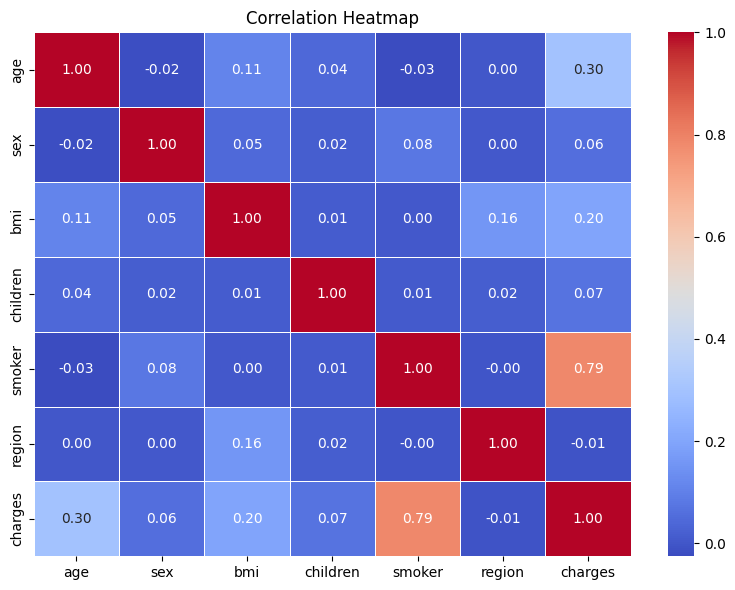


Korelasi dengan target (charges):
charges     1.000000
smoker      0.787234
age         0.298308
bmi         0.198401
children    0.067389
sex         0.058044
region     -0.006547
Name: charges, dtype: float64


In [11]:
df_encoded = df_clean.copy()
df_encoded['sex'] = df_encoded['sex'].map({'male': 1, 'female': 0})
df_encoded['smoker'] = df_encoded['smoker'].map({'yes': 1, 'no': 0})
df_encoded['region'] = df_encoded['region'].map({'northeast': 0, 'northwest': 1, 'southeast': 2, 'southwest': 3})

plt.figure(figsize=(8, 6))
corr = df_encoded.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan target (charges):')
print(corr['charges'].sort_values(ascending=False))

In [12]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[col] < lower) | (data[col] > upper)]
    return outliers, lower, upper

for col in ['age', 'bmi', 'charges']:
    outliers, lower, upper = detect_outliers_iqr(df_clean, col)
    print(f'{col}: {len(outliers)} outlier | lower={lower:.2f}, upper={upper:.2f}')

age: 0 outlier | lower=-9.00, upper=87.00
bmi: 9 outlier | lower=13.67, upper=47.32
charges: 139 outlier | lower=-13120.72, upper=34524.78


# **5. Data Preprocessing**

In [13]:
df_processed = df.copy()
before = len(df_processed)
df_processed = df_processed.drop_duplicates()
after = len(df_processed)
print(f'Duplikat dihapus: {before - after} baris')
print(f'Shape setelah hapus duplikat: {df_processed.shape}')

Duplikat dihapus: 1 baris
Shape setelah hapus duplikat: (1337, 7)


In [14]:
df_processed['sex'] = df_processed['sex'].map({'male': 1, 'female': 0})
df_processed['smoker'] = df_processed['smoker'].map({'yes': 1, 'no': 0})
df_processed = pd.get_dummies(df_processed, columns=['region'], drop_first=False)

print('Setelah encoding:')
print(df_processed.head())
print(f'\nShape: {df_processed.shape}')
print(f'Kolom: {list(df_processed.columns)}')

Setelah encoding:
   age  sex     bmi  children  smoker      charges  region_northeast  \
0   19    0  27.900         0       1  16884.92400             False   
1   18    1  33.770         1       0   1725.55230             False   
2   28    1  33.000         3       0   4449.46200             False   
3   33    1  22.705         0       0  21984.47061             False   
4   32    1  28.880         0       0   3866.85520             False   

   region_northwest  region_southeast  region_southwest  
0             False             False              True  
1             False              True             False  
2             False              True             False  
3              True             False             False  
4              True             False             False  

Shape: (1337, 10)
Kolom: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [15]:
Q1_bmi = df_processed['bmi'].quantile(0.25)
Q3_bmi = df_processed['bmi'].quantile(0.75)
IQR_bmi = Q3_bmi - Q1_bmi
lower_bmi = Q1_bmi - 1.5 * IQR_bmi
upper_bmi = Q3_bmi + 1.5 * IQR_bmi

df_processed['bmi'] = df_processed['bmi'].clip(lower=lower_bmi, upper=upper_bmi)
print(f'BMI setelah capping: min={df_processed["bmi"].min():.2f}, max={df_processed["bmi"].max():.2f}')

BMI setelah capping: min=15.96, max=47.32


In [16]:
X = df_processed.drop('charges', axis=1)
y = df_processed['charges']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nFitur: {list(X.columns)}')

Shape X: (1337, 9)
Shape y: (1337,)

Fitur: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

X_train shape: (1069, 9)
X_test shape: (268, 9)


In [18]:
scaler = StandardScaler()
num_features = ['age', 'bmi', 'children']

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print('Setelah StandardScaler:')
print(X_train[num_features].describe().round(3))

Setelah StandardScaler:
            age       bmi  children
count  1069.000  1069.000  1069.000
mean      0.000    -0.000     0.000
std       1.000     1.000     1.000
min      -1.515    -2.427    -0.908
25%      -0.872    -0.724    -0.908
50%      -0.014    -0.054    -0.071
75%       0.843     0.651     0.767
max       1.773     2.798     3.279


In [19]:
import os
os.makedirs('insurance_preprocessing', exist_ok=True)

train_data = X_train.copy()
train_data['charges'] = y_train.values

test_data = X_test.copy()
test_data['charges'] = y_test.values

train_data.to_csv('insurance_preprocessing/train.csv', index=False)
test_data.to_csv('insurance_preprocessing/test.csv', index=False)

print('Dataset hasil preprocessing berhasil disimpan!')
print(f'Train: {train_data.shape}')
print(f'Test: {test_data.shape}')

Dataset hasil preprocessing berhasil disimpan!
Train: (1069, 10)
Test: (268, 10)


In [20]:
print('=== Dataset Siap Latih ===')
print(f'Fitur: {list(X_train.columns)}')
print(f'Train size: {len(X_train)}')
print(f'Test size: {len(X_test)}')
print(f'\nTrain head:')
pd.read_csv('insurance_preprocessing/train.csv').head()

=== Dataset Siap Latih ===
Fitur: ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northeast', 'region_northwest', 'region_southeast', 'region_southwest']
Train size: 1069
Test size: 268

Train head:


,age,sex,bmi,children,smoker,region_northeast,region_northwest,region_southeast,region_southwest,charges
0,-1.157680,1,-1.002462,-0.907908,0,True,False,False,False,2396.09590
1,-1.300619,1,-0.796635,0.766904,0,True,False,False,False,3279.86855
2,0.914926,0,1.166632,0.766904,0,False,True,False,False,33471.97189
3,1.701087,1,1.824110,-0.907908,0,False,False,True,False,13405.39030
4,0.557580,0,-0.654140,0.766904,0,True,False,False,False,9715.84100
